<a href="https://colab.research.google.com/github/sanjeetgrewal/AIHC-5010-Winter-2026/blob/main/AIHC5010Hw1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

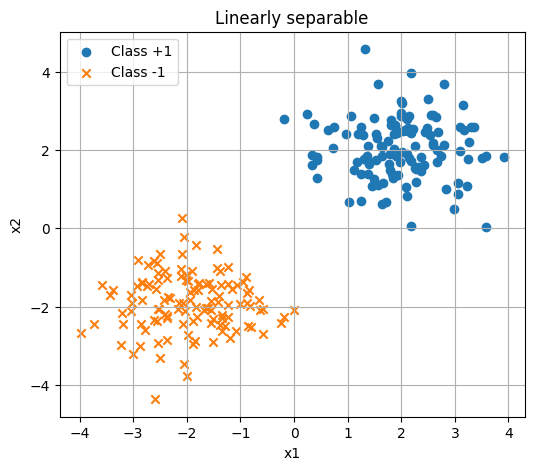

Epochs run: 2
Final training accuracy: 1.0
Weights: [2.52991333 1.33327554]
Bias: -1.0


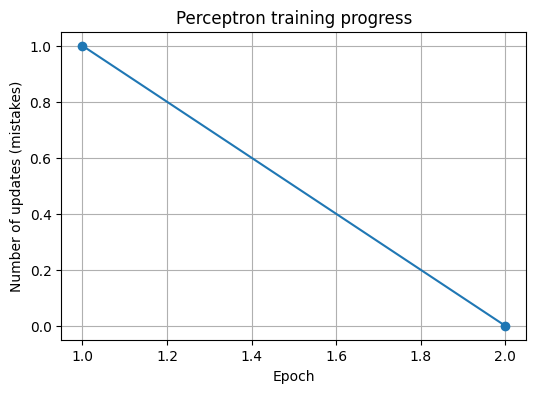

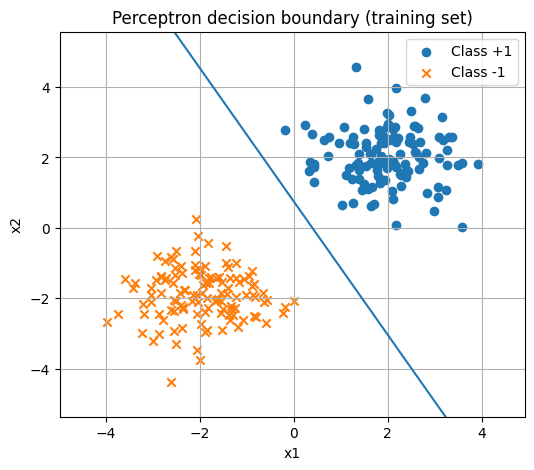

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


def make_linearly_separable_blobs(n_per_class: int = 120, seed: int = 3):
    rng = np.random.default_rng(seed)

    mean_pos = np.array([2.0, 2.0])
    mean_neg = np.array([-2.0, -2.0])

    cov = np.array([[0.6, 0.0],
                    [0.0, 0.6]])

    X_pos = rng.multivariate_normal(mean_pos, cov, size=n_per_class)
    X_neg = rng.multivariate_normal(mean_neg, cov, size=n_per_class)

    X = np.vstack([X_pos, X_neg])
    y = np.hstack([np.ones(n_per_class), -np.ones(n_per_class)])  # labels in {-1, +1}

    idx = rng.permutation(len(y))
    return X[idx], y[idx]


def plot_dataset(X, y, title="Dataset"):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[y == 1, 0], X[y == 1, 1], marker="o", label="Class +1")
    plt.scatter(X[y == -1, 0], X[y == -1, 1], marker="x", label="Class -1")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(True)
    plt.show()


class Perceptron:
    def __init__(self, learning_rate=1.0, max_epochs=50, shuffle=True, seed=0):
        self.learning_rate = float(learning_rate)
        self.max_epochs = int(max_epochs)
        self.shuffle = bool(shuffle)
        self.seed = int(seed)
        self.w_ = None
        self.b_ = None
        self.mistakes_per_epoch_ = []

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        if set(np.unique(y)) - {-1.0, 1.0}:
            raise ValueError("Labels must be in {-1, +1}.")

        n_samples, n_features = X.shape
        rng = np.random.default_rng(self.seed)

        self.w_ = np.zeros(n_features, dtype=float)
        self.b_ = 0.0
        self.mistakes_per_epoch_ = []

        for _ in range(self.max_epochs):
            if self.shuffle:
                idx = rng.permutation(n_samples)
                X_epoch, y_epoch = X[idx], y[idx]
            else:
                X_epoch, y_epoch = X, y

            mistakes = 0
            for xi, yi in zip(X_epoch, y_epoch):
                if yi * (np.dot(self.w_, xi) + self.b_) <= 0:
                    self.w_ += self.learning_rate * yi * xi
                    self.b_ += self.learning_rate * yi
                    mistakes += 1

            self.mistakes_per_epoch_.append(mistakes)
            if mistakes == 0:
                break

        return self

    def decision_function(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.w_ + self.b_

    def predict(self, X):
        scores = self.decision_function(X)
        return np.where(scores >= 0, 1.0, -1.0)

    def score(self, X, y):
        y = np.asarray(y, dtype=float)
        return float(np.mean(self.predict(X) == y))


def plot_training_progress(model):
    plt.figure(figsize=(6, 4))
    plt.plot(range(1, len(model.mistakes_per_epoch_) + 1),
             model.mistakes_per_epoch_,
             marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Number of updates (mistakes)")
    plt.title("Perceptron training progress")
    plt.grid(True)
    plt.show()


def plot_decision_boundary_2d(X, y, model, title="Decision boundary"):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[y == 1, 0], X[y == 1, 1], marker="o", label="Class +1")
    plt.scatter(X[y == -1, 0], X[y == -1, 1], marker="x", label="Class -1")

    w, b = model.w_, model.b_
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    if abs(w[1]) > 1e-12:
        xs = np.linspace(x_min, x_max, 200)
        ys = -(w[0] * xs + b) / w[1]
        plt.plot(xs, ys)
    else:
        x0 = -b / (w[0] + 1e-12)
        plt.axvline(x0)

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(True)
    plt.show()

X, y = make_linearly_separable_blobs(n_per_class=120, seed=3)
plot_dataset(X, y, title="Linearly separable")

model = Perceptron(learning_rate=1.0, max_epochs=50, shuffle=True, seed=42).fit(X, y)
print("Epochs run:", len(model.mistakes_per_epoch_))
print("Final training accuracy:", model.score(X, y))
print("Weights:", model.w_)
print("Bias:", model.b_)

plot_training_progress(model)
plot_decision_boundary_2d(X, y, model, title="Perceptron decision boundary (training set)")

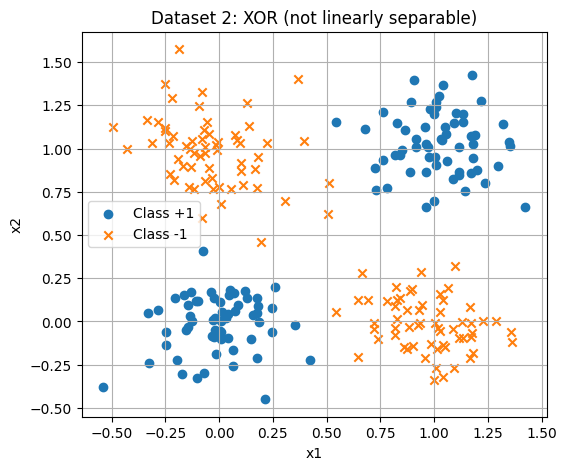

Perceptron training accuracy on XOR: 0.5
Final epoch mistakes: 110


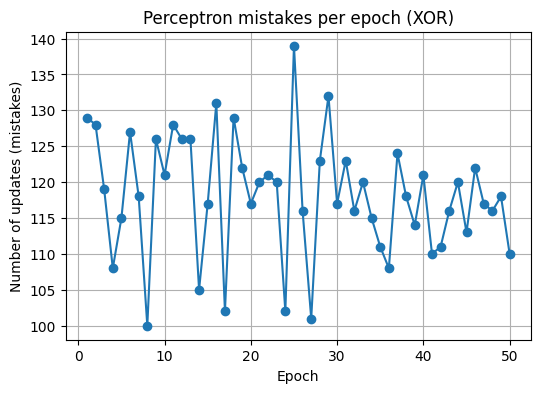

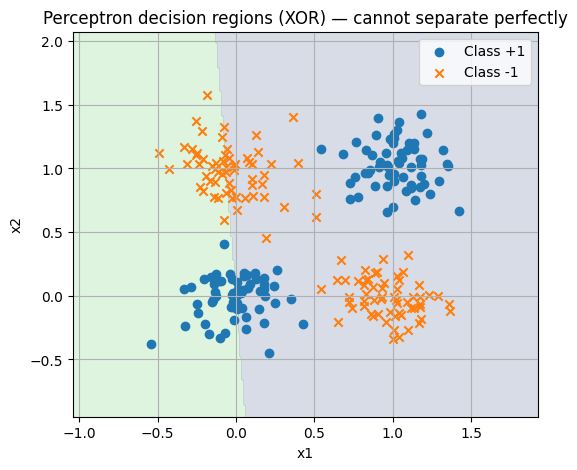

In [6]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def make_xor_dataset(n_per_corner: int = 50, noise: float = 0.20, seed: int = 0):
    rng = np.random.default_rng(seed)

    corners = np.array([
        [0.0, 0.0],  # +1
        [0.0, 1.0],  # -1
        [1.0, 0.0],  # -1
        [1.0, 1.0],  # +1
    ])
    labels = np.array([+1.0, -1.0, -1.0, +1.0])

    X_list, y_list = [], []
    for c, lab in zip(corners, labels):
        Xc = c + rng.normal(0.0, noise, size=(n_per_corner, 2))
        yc = np.full(n_per_corner, lab, dtype=float)
        X_list.append(Xc)
        y_list.append(yc)

    X = np.vstack(X_list)
    y = np.hstack(y_list)

    idx = rng.permutation(len(y))
    return X[idx], y[idx]


def plot_dataset(X, y, title="Dataset"):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[y == 1, 0], X[y == 1, 1], marker="o", label="Class +1")
    plt.scatter(X[y == -1, 0], X[y == -1, 1], marker="x", label="Class -1")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(True)
    plt.show()

class Perceptron:

    def __init__(self, learning_rate=1.0, max_epochs=100, shuffle=True, seed=0):
        self.learning_rate = float(learning_rate)
        self.max_epochs = int(max_epochs)
        self.shuffle = bool(shuffle)
        self.seed = int(seed)

        self.w_ = None
        self.b_ = None
        self.mistakes_per_epoch_ = []

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        if set(np.unique(y)) - {-1.0, 1.0}:
            raise ValueError("This implementation expects labels in {-1, +1}.")

        n_samples, n_features = X.shape
        rng = np.random.default_rng(self.seed)

        self.w_ = np.zeros(n_features, dtype=float)
        self.b_ = 0.0
        self.mistakes_per_epoch_ = []

        for _ in range(self.max_epochs):
            if self.shuffle:
                idx = rng.permutation(n_samples)
                X_epoch, y_epoch = X[idx], y[idx]
            else:
                X_epoch, y_epoch = X, y

            mistakes = 0
            for xi, yi in zip(X_epoch, y_epoch):
                if yi * (np.dot(self.w_, xi) + self.b_) <= 0:
                    self.w_ += self.learning_rate * yi * xi
                    self.b_ += self.learning_rate * yi
                    mistakes += 1

            self.mistakes_per_epoch_.append(mistakes)

            if mistakes == 0:
                break

        return self

    def decision_function(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.w_ + self.b_

    def predict(self, X):
        scores = self.decision_function(X)
        return np.where(scores >= 0, 1.0, -1.0)

    def score(self, X, y):
        y = np.asarray(y, dtype=float)
        return float(np.mean(self.predict(X) == y))


def plot_training_progress(model, title="Training progress"):
    plt.figure(figsize=(6, 4))
    plt.plot(
        range(1, len(model.mistakes_per_epoch_) + 1),
        model.mistakes_per_epoch_,
        marker="o",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Number of updates (mistakes)")
    plt.title(title)
    plt.grid(True)
    plt.show()


def plot_decision_boundary_2d(X, y, score_fn, title="Decision boundary"):
    plt.figure(figsize=(6, 5))

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = score_fn(grid).reshape(xx.shape)

    plt.contourf(xx, yy, zz >= 0, alpha=0.2)

    plt.scatter(X[y == 1, 0], X[y == 1, 1], marker="o", label="Class +1")
    plt.scatter(X[y == -1, 0], X[y == -1, 1], marker="x", label="Class -1")

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(True)
    plt.show()


X, y = make_xor_dataset(n_per_corner=60, noise=0.20, seed=1)
plot_dataset(X, y, title="Dataset 2: XOR (not linearly separable)")

p = Perceptron(learning_rate=1.0, max_epochs=50, shuffle=True, seed=42).fit(X, y)
print("Perceptron training accuracy on XOR:", p.score(X, y))
print("Final epoch mistakes:", p.mistakes_per_epoch_[-1])

plot_training_progress(p, title="Perceptron mistakes per epoch (XOR)")
plot_decision_boundary_2d(
    X, y, score_fn=lambda Z: p.decision_function(Z),
    title="Perceptron decision regions (XOR) — cannot separate perfectly"
)


Predicted probabilities:
 [[0.0013]
 [0.9957]
 [0.9966]
 [0.0063]]
Predicted labels:
 [0 1 1 0]
True labels:
 [0 1 1 0]
Accuracy: 1.0


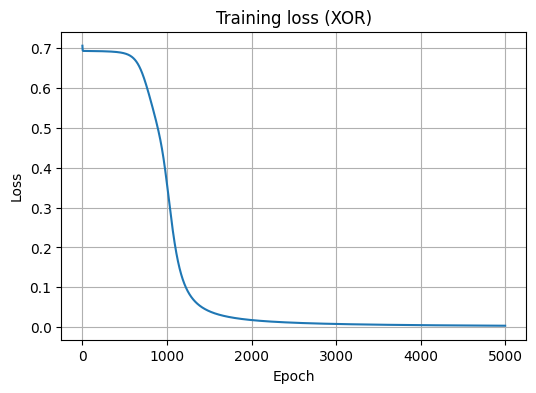

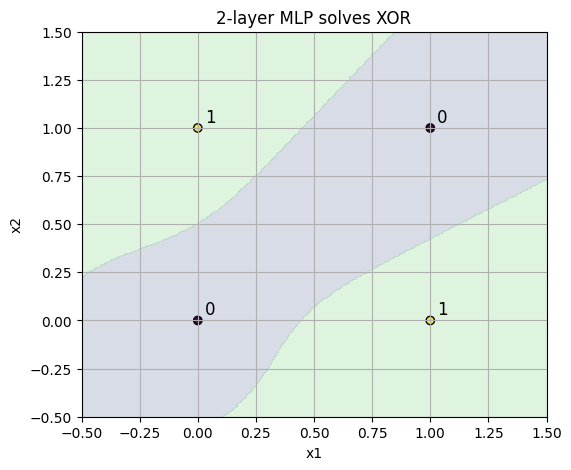

In [8]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

X = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
], dtype=float)

y = np.array([[0.0], [1.0], [1.0], [0.0]], dtype=float)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def train_xor_mlp(X, y, hidden=4, lr=0.5, epochs=5000, seed=0):
    rng = np.random.default_rng(seed)
    n, d = X.shape

    W1 = rng.normal(0, 1, size=(d, hidden)) / np.sqrt(d)
    b1 = np.zeros((1, hidden))
    W2 = rng.normal(0, 1, size=(hidden, 1)) / np.sqrt(hidden)
    b2 = np.zeros((1, 1))

    losses = []
    for _ in range(epochs):
        Z1 = X @ W1 + b1
        A1 = sigmoid(Z1)
        Z2 = A1 @ W2 + b2
        A2 = sigmoid(Z2)

        eps = 1e-12
        loss = -np.mean(y * np.log(A2 + eps) + (1 - y) * np.log(1 - A2 + eps))
        losses.append(loss)

        dZ2 = (A2 - y) / n
        dW2 = A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * A1 * (1 - A1)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    def predict_proba(Xnew):
        A1 = sigmoid(Xnew @ W1 + b1)
        A2 = sigmoid(A1 @ W2 + b2)
        return A2

    def predict(Xnew):
        return (predict_proba(Xnew) >= 0.5).astype(float)

    params = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    return params, losses, predict_proba, predict


params, losses, predict_proba, predict = train_xor_mlp(X, y, hidden=4, lr=0.5, epochs=5000, seed=1)

probs = predict_proba(X)
preds = predict(X)

print("Predicted probabilities:\n", probs.round(4))
print("Predicted labels:\n", preds.astype(int).ravel())
print("True labels:\n", y.astype(int).ravel())
print("Accuracy:", float(np.mean(preds == y)))

plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss (XOR)")
plt.grid(True)
plt.show()

def plot_decision_regions(predict_proba_fn, title="Decision regions"):
    xs = np.linspace(-0.5, 1.5, 250)
    ys = np.linspace(-0.5, 1.5, 250)
    xx, yy = np.meshgrid(xs, ys)
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = predict_proba_fn(grid).reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, zz >= 0.5, alpha=0.2)
    plt.scatter(X[:,0], X[:,1], c=y.ravel(), edgecolors="k")
    for i, (xi, yi) in enumerate(X):
        plt.text(xi + 0.03, yi + 0.03, str(int(y[i,0])), fontsize=12)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True)
    plt.show()

plot_decision_regions(predict_proba, title="2-layer MLP solves XOR")